In [1]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from itertools import chain
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
# Load the iclr-dataset parquet file
df = pd.read_parquet('../data/iclr26v1.parquet')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total number of papers: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")
print(f"\nShape: {df.shape}")

DATASET OVERVIEW
Total number of papers: 55,906
Number of columns: 10

Shape: (55906, 10)


In [30]:
# find the decision values counts for optimization in ["2020", "2021", "2022", "2023", "2024", "2025", "2026"]
df[(df['labels'] == 'optimization') & (df['year'].isin([2020, 2021,2022,2023,2024,2025,2026]))]['decision'].value_counts()

decision
Reject                     431
                           356
Accept (Poster)            137
Withdrawn                  123
Accept (poster)             56
Accept: poster              40
Accept (Spotlight)          22
Accept (spotlight)          12
Accept (Oral)                9
Desk rejected                9
Accept: notable-top-25%      5
Accept (Talk)                3
Accept (oral)                2
Accept: notable-top-5%       1
Name: count, dtype: int64

In [3]:
df.columns

Index(['year', 'id', 'title', 'abstract', 'authors', 'author_ids', 'decision',
       'scores', 'keywords', 'labels'],
      dtype='object')

In [4]:
df['year'].value_counts()

year
2026    19793
2025    11663
2024     7401
2023     4955
2022     3422
2021     3009
2020     2593
2019     1569
2018     1012
2017      489
Name: count, dtype: int64

In [5]:
df['labels'].value_counts()

labels
unlabeled                     25371
LLMs                           4116
RL                             2178
language models                1773
diffusion models               1749
graphs                         1404
optimization                   1382
adversarial                    1310
transformers                   1048
self-supervised learning        857
transfer learning               664
continual learning              567
federated learning              567
vision-language models          553
out-of-distribution             485
autoencoders                    459
causality                       454
GANs                            453
privacy                         451
time series                     439
safety                          438
interpretability                426
alignment                       411
explainability                  408
compression                     399
multi-agent RL                  390
meta learning                   387
RNNs                 


Labels after filtering:
labels
LLMs               4116
RL                 2178
language models    1773
optimization       1382
Name: count, dtype: int64


Summary Statistics:
LLMs               4116
RL                 2178
Language Models    1773
Optimization       1382
dtype: int64

Total papers: 9449
Years covered: 10

DataFrame shape: (10, 4)
DataFrame columns: ['LLMs', 'Optimization', 'RL', 'Language Models']
      LLMs  Optimization   RL  Language Models
year                                          
2017     0            45   31               82
2018     1            40   84               36
2019    10            91  112               41
2020    38            80  187               77
2021    28            84  176               85
2022    25           105  175               75
2023    47           125  170              119
2024   441           198  270              235
2025  1143           255  271              336
2026  2383           359  702              687


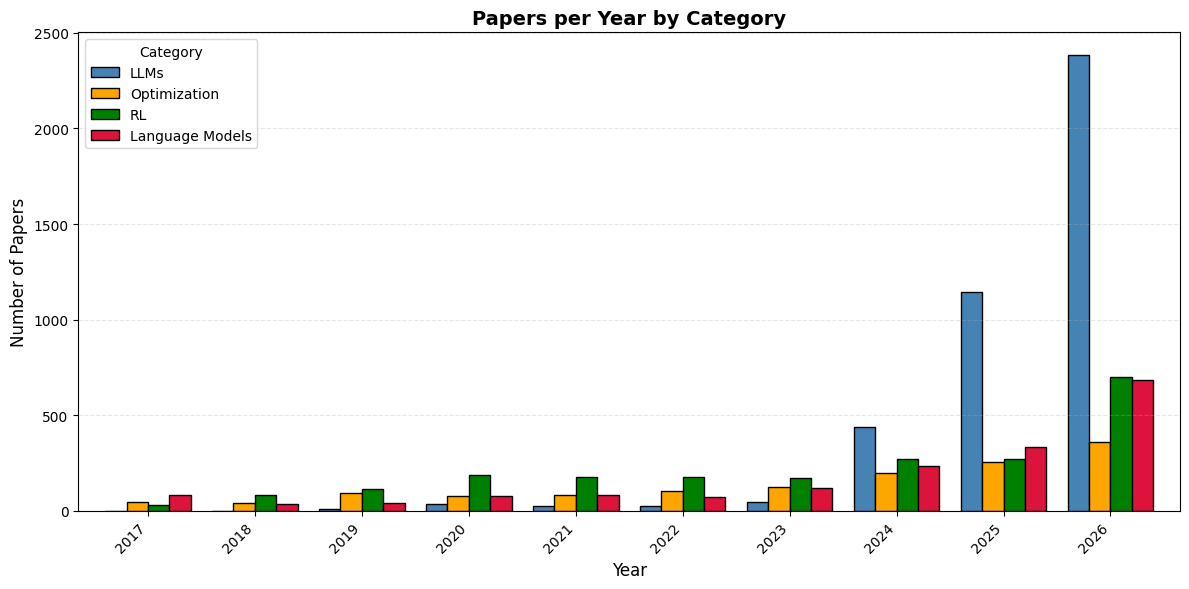

In [6]:
# Only keeping those papers in LLMs, optimization, RL, and language models
keep_list = ['LLMs', 'RL', 'optimization', 'language models']
df_filtered = df[df['labels'].isin(keep_list)]

print(f"\nLabels after filtering:")
print(df_filtered['labels'].value_counts())
print("\n" + "="*60)

# Count papers per year for each category
LLM_counts = df_filtered[df_filtered['labels'] == 'LLMs']['year'].value_counts().sort_index()
Optimization_counts = df_filtered[df_filtered['labels'] == 'optimization']['year'].value_counts().sort_index()
RL_counts = df_filtered[df_filtered['labels'] == 'RL']['year'].value_counts().sort_index()
Language_Models_counts = df_filtered[df_filtered['labels'] == 'language models']['year'].value_counts().sort_index()

# Combine into a DataFrame for grouped bar chart
comparison_df = pd.DataFrame({
    'LLMs': LLM_counts,
    'Optimization': Optimization_counts,
    'RL': RL_counts,
    'Language Models': Language_Models_counts
}).fillna(0).astype(int)  # Fill missing years with 0 and convert to int

# Print summary statistics
print("\n" + "="*60)
print("Summary Statistics:")
print(comparison_df.sum().sort_values(ascending=False))
print(f"\nTotal papers: {comparison_df.sum().sum()}")
print(f"Years covered: {len(comparison_df)}")
print(f"\nDataFrame shape: {comparison_df.shape}")
print(f"DataFrame columns: {list(comparison_df.columns)}")
print(comparison_df.head(10))

# Plot as grouped bar chart
# Only plot categories that have data
categories_with_data = [col for col in comparison_df.columns if comparison_df[col].sum() > 0]
colors_map = {
    'LLMs': 'steelblue',
    'Optimization': 'orange', 
    'RL': 'green',
    'Language Models': 'crimson'
}
colors = [colors_map[cat] for cat in categories_with_data if cat in colors_map]

if len(categories_with_data) > 0:
    ax = comparison_df[categories_with_data].plot(kind='bar', figsize=(12, 6), 
                            color=colors, 
                            edgecolor='black', width=0.8)
    
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Papers', fontsize=12)
    plt.title('Papers per Year by Category', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Category', fontsize=10, loc='upper left')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()  
    plt.show()
else:
    print("No data to plot!")

In [7]:
df_filtered.columns

Index(['year', 'id', 'title', 'abstract', 'authors', 'author_ids', 'decision',
       'scores', 'keywords', 'labels'],
      dtype='object')

In [8]:
df_filtered['labels'].value_counts()

labels
LLMs               4116
RL                 2178
language models    1773
optimization       1382
Name: count, dtype: int64

In [9]:
splits = ["2020", "2021", "2022", "2023", "2024", "2025", "2026"]
columns_to_keep = [
    'submission_id',
    'year',
    'openreview_link',
    'pdf_download_link',
    'title',
    'clean_md',
    'original_abstract',
    'original_reviews',
    'normalized_reviews',
    'original_metareview',
    'technical_indicators'
]

streams = [
    load_dataset(
        "skonan/iclr-reviews-2020-2026",
        split=s,
        streaming=True
    )
    for s in splits
]

df_with_rebuttal = pd.DataFrame(
    {col: row.get(col) for col in columns_to_keep}
    for row in chain.from_iterable(streams)
)

df_with_rebuttal.head() # dataframe from auto reviewer


,submission_id,year,openreview_link,pdf_download_link,title,clean_md,original_abstract,original_reviews,normalized_reviews,original_metareview,technical_indicators
0,ryxz8CVYDH,2020,https://openreview.net/forum?id=ryxz8CVYDH,https://openreview.net/pdf/07a4b4b413b37f2c43c...,Learning to Learn by Zeroth-Order Oracle,\n# 1 INTRODUCTION\n\n\nLearning to learn (L2L...,"In the learning to learn (L2L) framework, we c...","[{""rating"": ""6: Weak Accept"", ""review"": ""The p...","[""{\""summary\"":\""The paper introduces a zeroth...","{""decision"": ""Accept (Poster)"", ""comment"": ""Th...","{""binary_decision"": ""accept"", ""specific_decisi..."
1,ryxyCeHtPB,2020,https://openreview.net/forum?id=ryxyCeHtPB,https://openreview.net/pdf/84d13359f1520c521f1...,"Pay Attention to Features, Transfer Learn Fast...",\n# 1 INTRODUCTION\n\n\nDespite recent success...,Deep convolutional neural networks are now wid...,"[{""rating"": ""6: Weak Accept"", ""review"": "" This...","[""{\""summary\"":\""The paper introduces Attentiv...","{""decision"": ""Accept (Poster)"", ""comment"": ""Th...","{""binary_decision"": ""accept"", ""specific_decisi..."
2,ryxtWgSKPB,2020,https://openreview.net/forum?id=ryxtWgSKPB,https://openreview.net/pdf/e90a912a0f6b4596f6b...,Quantum Optical Experiments Modeled by Long Sh...,"\n# 1 INTRODUCTION\n\n\nIn the past decade, ar...",We demonstrate how machine learning is able to...,"[{""rating"": ""3: Weak Reject"", ""review"": ""This ...","[""{\""summary\"":\""The paper proposes using mach...","{""decision"": ""Reject"", ""comment"": ""The paper p...","{""binary_decision"": ""reject"", ""specific_decisi..."
3,ryxtCpNtDS,2020,https://openreview.net/forum?id=ryxtCpNtDS,https://openreview.net/pdf/7d53de57a3ebd9cc3bb...,Autoencoders and Generative Adversarial Networ...,\nDealing with imbalanced datasets is the crux...,We introduce a novel synthetic oversampling me...,"[{""rating"": ""3: Weak Reject"", ""review"": ""The p...","[""{\""summary\"":\""The paper addresses an import...","{""decision"": ""Reject"", ""comment"": ""This paper ...","{""binary_decision"": ""reject"", ""specific_decisi..."
4,ryxsUySFwr,2020,https://openreview.net/forum?id=ryxsUySFwr,https://openreview.net/pdf/89002f34556ae166746...,Neural Network Out-of-Distribution Detection f...,\n# 1 INTRODUCTION\n\n\nThe success of deep ne...,Neural network out-of-distribution (OOD) detec...,"[{""rating"": ""3: Weak Reject"", ""review"": ""The a...","[""{\""summary\"":\""The paper presents an empiric...","{""decision"": ""Reject"", ""comment"": ""The paper i...","{""binary_decision"": ""reject"", ""specific_decisi..."


In [10]:
df_with_rebuttal['bin_decision'] = df_with_rebuttal['technical_indicators'].apply(
    lambda x: json.loads(x)['binary_decision'] if pd.notna(x) and x else None
)


print(df_with_rebuttal['bin_decision'].value_counts())
# bin_decision for the year 2026 is all reject, weird?

print('\n year 2023', df_with_rebuttal[df_with_rebuttal['year'] == 2023]['bin_decision'].value_counts()) 

print('\n year 2024', df_with_rebuttal[df_with_rebuttal['year'] == 2024]['bin_decision'].value_counts())

print('\n year 2025', df_with_rebuttal[df_with_rebuttal['year'] == 2025]['bin_decision'].value_counts())

print('\nyear 2026', df_with_rebuttal[df_with_rebuttal['year'] == 2026]['bin_decision'].value_counts()) # all reject weird??



bin_decision
reject    30388
accept     9988
Name: count, dtype: int64

 year 2023 bin_decision
reject    2212
accept    1571
Name: count, dtype: int64

 year 2024 bin_decision
reject    3509
accept    2255
Name: count, dtype: int64

 year 2025 bin_decision
reject    4774
accept    3556
Name: count, dtype: int64

year 2026 bin_decision
reject    15193
Name: count, dtype: int64


In [30]:
# import json

# # Extract decision from original_metareview (handle both formats)
# def extract_metareview_decision(x):
#     if pd.notna(x) and x:
#         try:
#             parsed = json.loads(x)
#             # First try 'decision' key
#             if 'decision' in parsed:
#                 return parsed['decision']
#             # If not, check if there's a 'metareview' key that might contain decision info
#             elif 'metareview' in parsed:
#                 # You might need to parse the metareview text to extract decision
#                 # Or return the metareview itself
#                 return parsed.get('metareview')
#             else:
#                 return None
#         except:
#             return None
#     return None

# df_with_rebuttal['metareview_decision'] = df_with_rebuttal['original_metareview'].apply(extract_metareview_decision)

In [31]:
# df_with_rebuttal['metareview_decision'].value_counts()

In [11]:
df_with_rebuttal = df_with_rebuttal[df_with_rebuttal['submission_id'].isin(df_filtered['id'])]

In [12]:
df_with_rebuttal.shape

(7056, 12)

In [13]:
df_with_rebuttal.columns

Index(['submission_id', 'year', 'openreview_link', 'pdf_download_link',
       'title', 'clean_md', 'original_abstract', 'original_reviews',
       'normalized_reviews', 'original_metareview', 'technical_indicators',
       'bin_decision'],
      dtype='object')

In [14]:
# Inner join: df has `id` column, df_with_rebuttal has `submission_id` column
# Common columns: 'year' and 'title' - we'll keep them from df and drop from df_with_rebuttal

# Identify common columns (excluding the join keys)
common_cols = set(df.columns) & set(df_with_rebuttal.columns)
# Remove the join key columns from common columns
common_cols = common_cols - {'id', 'submission_id'}
print(f"Common columns (will keep from df): {common_cols}")

# Drop common columns from df_with_rebuttal to avoid _x/_y suffixes
df_with_rebuttal_clean = df_with_rebuttal.drop(columns=list(common_cols))
print(f"\ndf_with_rebuttal columns after dropping duplicates: {list(df_with_rebuttal_clean.columns)}")

# Merge: use left_on and right_on to specify different column names
df_merged = pd.merge(
    df, 
    df_with_rebuttal_clean, 
    left_on='id',           # Column name in df
    right_on='submission_id',  # Column name in df_with_rebuttal
    how='inner'
)

print(f"\nOriginal df shape: {df.shape}")
print(f"df_with_rebuttal shape: {df_with_rebuttal.shape}")
print(f"Merged df shape: {df_merged.shape}")
print(f"\nColumns in merged df ({len(df_merged.columns)}): {list(df_merged.columns)}")

df_merged.head()



Common columns (will keep from df): {'year', 'title'}

df_with_rebuttal columns after dropping duplicates: ['submission_id', 'openreview_link', 'pdf_download_link', 'clean_md', 'original_abstract', 'original_reviews', 'normalized_reviews', 'original_metareview', 'technical_indicators', 'bin_decision']

Original df shape: (55906, 10)
df_with_rebuttal shape: (7056, 12)
Merged df shape: (7056, 20)

Columns in merged df (20): ['year', 'id', 'title', 'abstract', 'authors', 'author_ids', 'decision', 'scores', 'keywords', 'labels', 'submission_id', 'openreview_link', 'pdf_download_link', 'clean_md', 'original_abstract', 'original_reviews', 'normalized_reviews', 'original_metareview', 'technical_indicators', 'bin_decision']


,year,id,title,abstract,authors,author_ids,decision,scores,keywords,labels,submission_id,openreview_link,pdf_download_link,clean_md,original_abstract,original_reviews,normalized_reviews,original_metareview,technical_indicators,bin_decision
0,2020,B1eP504YDr,Independence-aware Advantage Estimation,Most of existing advantage function estimation...,"Pushi Zhang, Li Zhao, Guoqing Liu, Jiang Bian,...",,Reject,"[3, 6, 6]","[reinforcement learning, advantage estimation]",RL,B1eP504YDr,https://openreview.net/forum?id=B1eP504YDr,https://openreview.net/pdf/8cf38e2a4db1bae863b...,\n# 1 INTRODUCTION\n\n\nPolicy gradient method...,Most of existing advantage function estimation...,"[{""rating"": ""6: Weak Accept"", ""review"": ""This ...","[""{\""summary\"":\""The paper introduces a novel ...","{""decision"": ""Reject"", ""comment"": ""Policy grad...","{""binary_decision"": ""reject"", ""specific_decisi...",reject
1,2020,B1eQcCEtDB,"Calibration, Entropy Rates, and Memory in Lang...",Building accurate language models that capture...,"Mark Braverman, Xinyi Chen, Sham Kakade, Karth...",,Reject,"[6, 3, 6]","[information theory, natural language processi...",language models,B1eQcCEtDB,https://openreview.net/forum?id=B1eQcCEtDB,https://openreview.net/pdf/a90ed63bae5fe4f63a5...,\n# 1 INTRODUCTION\n\n\nRecent advances in lan...,Building accurate language models that capture...,"[{""rating"": ""6: Weak Accept"", ""review"": ""This ...","[""{\""summary\"":\""The paper introduces and anal...","{""decision"": ""Reject"", ""comment"": ""This paper ...","{""binary_decision"": ""reject"", ""specific_decisi...",reject
2,2020,B1em8TVtPr,Discourse-Based Evaluation of Language Underst...,New models for natural language understanding ...,"Damien Sileo, Tim Van-De-Cruys, Camille Pradel...",,Reject,"[6, 6, 6]","[natural language understanding, pragmatics, d...",LLMs,B1em8TVtPr,https://openreview.net/forum?id=B1em8TVtPr,https://openreview.net/pdf/e63bf8f10a391718178...,"\n# 1 INTRODUCTION\n\n\nOver the last year, no...",New models for natural language understanding ...,"[{""rating"": ""6: Weak Accept"", ""review"": ""\nThe...","[""{\""summary\"":\""The paper introduces DiscEval...","{""decision"": ""Reject"", ""comment"": ""This paper ...","{""binary_decision"": ""reject"", ""specific_decisi...",reject
3,2020,B1erJJrYPH,Optimizing Loss Landscape Connectivity via Neu...,The loss landscapes of deep neural networks ar...,"N. Joseph Tatro, Pin-Yu Chen, Payel Das, Igor ...",,Reject,"[3, 6, 1]","[deep learning, optimization, non-convex optim...",optimization,B1erJJrYPH,https://openreview.net/forum?id=B1erJJrYPH,https://openreview.net/pdf/917dc8e3624d084490c...,\n# 1 INTRODUCTION\n\n\nLoss surfaces of neura...,The loss landscapes of deep neural networks ar...,"[{""rating"": ""1: Reject"", ""review"": ""Given two ...","[""{\""summary\"":\""The paper proposes learning a...","{""decision"": ""Reject"", ""comment"": ""This paper ...","{""binary_decision"": ""reject"", ""specific_decisi...",reject
4,2020,B1g5sA4twr,Deep Double Descent: Where Bigger Models and M...,We show that a variety of modern deep learning...,"Preetum Nakkiran, Gal Kaplun, Yamini Bansal, T...",,Accept (Poster),"[8, 6, 6]","[deep learning, double descent, optimization, ...",optimization,B1g5sA4twr,https://openreview.net/forum?id=B1g5sA4twr,https://openreview.net/pdf/3804e75d7bf7d929488...,\n# 1 INTRODUCTION\n\n\n![Figure 1: Left: Trai...,We show that a variety of modern deep learning...,"[{""rating"": ""6: Weak Accept"", ""review"": ""I do ...","[""{\""summary\"":\""The reviewer generally suppor...","{""decision"": ""Accept (Poster)"", ""comment"": ""Th...","{""binary_decision"": ""accept"", ""specific_decisi...",accept


In [32]:
df_merged[(df_merged['labels'] == 'optimization')]['decision'].value_counts()

decision
Reject                     420
                           297
Accept (Poster)            131
Accept (poster)             56
Accept: poster              40
Accept (Spotlight)          21
Accept (spotlight)          12
Accept (Oral)                9
Accept: notable-top-25%      5
Accept (Talk)                3
Accept (oral)                2
Withdrawn                    2
Accept: notable-top-5%       1
Name: count, dtype: int64

In [15]:
df_merged['labels'].value_counts() # 74 papers on optimization in 2020, 

labels
LLMs               3163
RL                 1614
language models    1280
optimization        999
Name: count, dtype: int64

In [16]:
df_with_rebuttal.shape, df_merged.shape

((7056, 12), (7056, 20))

In [17]:
print(df_merged['decision'].value_counts()) # `decision` column comes from the iclr-dataset

# show the decision value counts over the years, some years use accept notable top-25 % etc
print("Unique decision values by year:")
print("=" * 60)
for year in sorted(df_merged['year'].unique()):
    unique_decisions = df_merged[df_merged['year'] == year]['decision'].unique()
    print(f"\n{year}:")
    print(f"  {sorted(unique_decisions)}")

decision
                           3303
Reject                     2157
Accept (Poster)             807
Accept (poster)             309
Accept: poster              132
Accept (Spotlight)          131
Accept (spotlight)           69
Accept (Oral)                67
Accept: notable-top-25%      28
Accept (oral)                19
Withdrawn                    15
Accept (Talk)                10
Accept: notable-top-5%        9
Name: count, dtype: int64
Unique decision values by year:

2020:
  ['Accept (Poster)', 'Accept (Spotlight)', 'Accept (Talk)', 'Reject']

2021:
  ['Accept (Oral)', 'Accept (Poster)', 'Accept (Spotlight)', 'Reject']

2022:
  ['Accept (Oral)', 'Accept (Poster)', 'Accept (Spotlight)', 'Reject']

2023:
  ['Accept: notable-top-25%', 'Accept: notable-top-5%', 'Accept: poster', 'Reject']

2024:
  ['Accept (oral)', 'Accept (poster)', 'Accept (spotlight)', 'Reject', 'Withdrawn']

2025:
  ['Accept (Oral)', 'Accept (Poster)', 'Accept (Spotlight)', 'Reject', 'Withdrawn']

2026:
  [

In [22]:
# Types of decisions
# 1) 'Accept (Poster)', 'Accept: poster', 'Accept (poster)',
# 2) 'Accept (spotlight)', 'Accept (Spotlight)',  'Accept: notable-top-25%', 
# 3) 'Accept (Talk)', 'Accept (oral)', 'Accept: notable-top-5%'
# 4) 'Withdrawn', 'Reject'


# 2023 had these not standard tags
#   ['Accept: notable-top-25%', 'Accept: notable-top-5%', 'Accept: poster', 'Reject']

def normalize_decision(decision):
    if pd.isna(decision):
        return None
    
    decision_lower = str(decision).lower()
    
    # accept-poster
    if 'poster' in decision_lower:
        return 'accept-poster'
    
    # accept-spotlight (includes notable-top-25%)
    elif 'spotlight' in decision_lower or 'notable-top-25%' in decision_lower:
        return 'accept-spotlight'
    
    # accept-oral (includes Talk, oral, notable-top-5%)
    elif 'oral' in decision_lower or 'talk' in decision_lower or 'notable-top-5%' in decision_lower:
        return 'accept-oral'
    
    # withdrawn
    elif 'withdrawn' in decision_lower:
        return 'withdrawn'
    
    # reject
    elif 'reject' in decision_lower:
        return 'reject'
    
    else:
        return None

df_merged['decision_normalized'] = df_merged['decision'].apply(normalize_decision)


In [25]:
df_merged['decision_normalized'].value_counts()

decision_normalized
reject              2157
accept-poster       1248
accept-spotlight     228
accept-oral          105
withdrawn             15
Name: count, dtype: int64

In [33]:
df_merged[df_merged['year'] == 2026]['decision_normalized'].value_counts()  # all empty strings
# 2026 has an issue in parsing decision in iclr-dataset, instead use skonan/iclr-reviews-2020-2026 technical_indicators

Series([], Name: count, dtype: int64)

In [34]:
df_merged[df_merged['year'] == 2025]['bin_decision'].value_counts(), df_merged[df_merged['year'] == 2026]['bin_decision'].value_counts() # weird that all are reject for 2026?

(bin_decision
 reject    824
 accept    656
 Name: count, dtype: int64,
 bin_decision
 reject    3303
 Name: count, dtype: int64)

In [ ]:
# Note you need to be logged in to openreview to see the revision history.
# https://openreview.net/forum?id=rkeNfp4tPr from 2020
# https://openreview.net/forum?id=BJgnXpVYwS from 2021

In [35]:
seed = 42
# 5 random papers on optimization from 2020
optimization_2020 = df_merged[(df_merged['labels'] == 'optimization') & (df_merged['year'] == 2020)]
random_opt_papers = optimization_2020.sample(n=5, random_state=seed)

In [36]:
random_opt_papers.columns


Index(['year', 'id', 'title', 'abstract', 'authors', 'author_ids', 'decision',
       'scores', 'keywords', 'labels', 'submission_id', 'openreview_link',
       'pdf_download_link', 'clean_md', 'original_abstract',
       'original_reviews', 'normalized_reviews', 'original_metareview',
       'technical_indicators', 'bin_decision', 'decision_normalized'],
      dtype='object')

In [38]:
random_opt_papers['decision_normalized'].value_counts()

decision_normalized
reject           4
accept-poster    1
Name: count, dtype: int64

In [39]:
random_opt_papers[['openreview_link','decision_normalized','title','pdf_download_link', 'clean_md', 'normalized_reviews']]


,openreview_link,decision_normalized,title,pdf_download_link,clean_md,normalized_reviews
17,https://openreview.net/forum?id=B1lxV6NFPH,reject,BANANAS: Bayesian Optimization with Neural Net...,https://openreview.net/pdf/487a6256ad818b3bd5d...,\n# 1 INTRODUCTION\n\n\nSince the deep learnin...,"[""{\""summary\"":\""The paper proposes a path-bas..."
284,https://openreview.net/forum?id=rkeNfp4tPr,accept-poster,Escaping Saddle Points Faster with Stochastic ...,https://openreview.net/pdf/47dafa6caa94031872d...,\n# 1 INTRODUCTION\n\n\nSGD with stochastic mo...,"[""{\""summary\"":\""The paper analyzes SGD with m..."
77,https://openreview.net/forum?id=Byxv2pEKPH,reject,"Farkas layers: don't shift the data, fix the g...",https://openreview.net/pdf/8eeb0edf5eac4207e58...,\n# 1 INTRODUCTION\n\n\nThe training process o...,"[""{\""summary\"":\""The paper introduces Farkas l..."
3,https://openreview.net/forum?id=B1erJJrYPH,reject,Optimizing Loss Landscape Connectivity via Neu...,https://openreview.net/pdf/917dc8e3624d084490c...,\n# 1 INTRODUCTION\n\n\nLoss surfaces of neura...,"[""{\""summary\"":\""The paper proposes learning a..."
135,https://openreview.net/forum?id=Hklcm0VYDS,reject,How noise affects the Hessian spectrum in over...,https://openreview.net/pdf/fc79c0c9ba8f2e87f1e...,\n# 1 INTRODUCTION\n\n\nDeep neural networks h...,"[""{\""summary\"":\""The paper investigates how no..."


In [40]:
import os
from pathlib import Path
import requests
from urllib.parse import urlparse

# TODO: 
# output to a folder with data_papers/year/labels/`id-title`.pdf and markdown to data_papers/year/`labels`/`id-title`.md
# clean_md has the markdown of the pdf save it in data_papers/year/`labels`/accepted/`id-title`.md

def sanitize_filename(filename):
    """Remove invalid characters from filename"""
    invalid_chars = '<>:"/\\|?*'
    for char in invalid_chars:
        filename = filename.replace(char, '_')
    return filename.strip()

def save_paper_files(df, base_dir='data_papers'):
    """
    Save PDFs and markdown files for papers in the dataframe
    """
    base_path = Path(base_dir)
    
    for idx, row in df.iterrows():
        year = str(row['year'])
        labels = str(row['labels']).replace(' ', '_')  # Replace spaces with underscores
        paper_id = str(row['id'])
        title = sanitize_filename(str(row['title']))
        filename = f"{paper_id}-{title}"  # id-title format
        clean_md = row.get('clean_md', '')
        pdf_link = row.get('pdf_download_link', '')
        
        # Create directory structure: data_papers/year/labels/
        paper_dir = base_path / year / labels
        paper_dir.mkdir(parents=True, exist_ok=True)
        
        # Create accepted subdirectory for markdown
        accepted_dir = paper_dir / 'accepted'
        accepted_dir.mkdir(parents=True, exist_ok=True)
        
        # Save markdown file
        if clean_md and pd.notna(clean_md):
            md_file = accepted_dir / f"{filename}.md"
            with open(md_file, 'w', encoding='utf-8') as f:
                f.write(clean_md)
            print(f"Saved markdown: {md_file}")
        
        # Download and save PDF file
        if pdf_link and pd.notna(pdf_link):
            pdf_file = paper_dir / f"{filename}.pdf"
            try:
                response = requests.get(pdf_link, timeout=30)
                if response.status_code == 200:
                    with open(pdf_file, 'wb') as f:
                        f.write(response.content)
                    print(f"Saved PDF: {pdf_file}")
                else:
                    print(f"Failed to download PDF for {filename}: Status {response.status_code}")
            except Exception as e:
                print(f"Error downloading PDF for {filename}: {e}")

# Run for random_opt_papers
save_paper_files(random_opt_papers)

Saved markdown: data_papers/2020/optimization/accepted/B1lxV6NFPH-BANANAS_ Bayesian Optimization with Neural Networks for Neural Architecture Search.md
Saved PDF: data_papers/2020/optimization/B1lxV6NFPH-BANANAS_ Bayesian Optimization with Neural Networks for Neural Architecture Search.pdf
Saved markdown: data_papers/2020/optimization/accepted/rkeNfp4tPr-Escaping Saddle Points Faster with Stochastic Momentum.md
Failed to download PDF for rkeNfp4tPr-Escaping Saddle Points Faster with Stochastic Momentum: Status 404
Saved markdown: data_papers/2020/optimization/accepted/Byxv2pEKPH-Farkas layers_ don't shift the data, fix the geometry.md
Saved PDF: data_papers/2020/optimization/Byxv2pEKPH-Farkas layers_ don't shift the data, fix the geometry.pdf
Saved markdown: data_papers/2020/optimization/accepted/B1erJJrYPH-Optimizing Loss Landscape Connectivity via Neuron Alignment.md
Saved PDF: data_papers/2020/optimization/B1erJJrYPH-Optimizing Loss Landscape Connectivity via Neuron Alignment.pdf
Sa

In [84]:
print(random_papers.head()['original_reviews'].iloc[0])

[{"rating": "3: Weak Reject", "review": "The paper considers the neural architecture search using Bayesian optimisation. The paper first propose a path-based encoding scheme to featurise the neural architectures. A path encoding of a cell is created by enumerating all possible paths from the input node to the output node. Then, they propose to train 5 neural networks and ensemble these networks to get the prediction (including the predictive value and uncertainty). The paper optimises the acquisition function via a mutation procedure, where we randomly mutate the best architectures that we have trained so far, many times, and then select the architecture from this set which minimizes the acquisition function.\n\nWhile the writing is readable and the experiments seem promising, the reviewer thinks that the novelty and contribution of the paper are limited. Particularly, using 5 neural networks for estimating the uncertainty is less convincing. This is because it would have been better i

In [2]:
print("=" * 60)
print("SCHEMA / COLUMN INFORMATION")
print("=" * 60)
print("\nColumn names and data types:")
print(df.dtypes)
print("\n" + "-" * 60)
print("\nColumn details:")
for col in df.columns:
    print(f"\n{col}:")
    print(f"  Type: {df[col].dtype}")
    if df[col].dtype == 'object':
        # For object types, show sample values
        sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else None
        if isinstance(sample, list):
            print(f"  Sample value: {sample[:3] if len(sample) > 3 else sample} (list with {len(sample)} items)")
        else:
            print(f"  Sample value: {str(sample)[:100] if sample is not None else 'N/A'}")
    print(f"  Non-null count: {df[col].notna().sum():,} / {len(df):,}")
    print(f"  Null count: {df[col].isna().sum():,}")

SCHEMA / COLUMN INFORMATION

Column names and data types:
year           int64
id            object
title         object
abstract      object
authors       object
author_ids    object
decision      object
scores        object
keywords      object
labels        object
dtype: object

------------------------------------------------------------

Column details:

year:
  Type: int64
  Non-null count: 55,906 / 55,906
  Null count: 0

id:
  Type: object
  Sample value: B1-Hhnslg
  Non-null count: 55,906 / 55,906
  Null count: 0

title:
  Type: object
  Sample value: Prototypical Networks for Few-shot Learning
  Non-null count: 55,906 / 55,906
  Null count: 0

abstract:
  Type: object
  Sample value: A recent approach to few-shot classification called matching networks has demonstrated the benefits 
  Non-null count: 55,906 / 55,906
  Null count: 0

authors:
  Type: object
  Sample value: Jake Snell, Kevin Swersky, Richard Zemel
  Non-null count: 55,906 / 55,906
  Null count: 0

author_ids:
 

In [5]:
print("=" * 60)
print("ADDITIONAL ANALYSIS")
print("=" * 60)

# Check for decision column
if 'decision' in df.columns:
    print("\nDecision distribution:")
    decision_counts = df['decision'].value_counts()
    print(decision_counts)
    print(f"\nAcceptance rate (if 'Accept' in decisions):")
    if any('Accept' in str(d) for d in decision_counts.index):
        accept_cols = [d for d in decision_counts.index if 'Accept' in str(d)]
        accept_count = sum(decision_counts[d] for d in accept_cols)
        print(f"  Accepted: {accept_count:,} ({100*accept_count/len(df):.1f}%)")
        print(f"  Total: {len(df):,}")

# Check for scores column
if 'scores' in df.columns:
    print("\n" + "-" * 60)
    print("\nScore statistics:")
    # Calculate average scores for papers with scores
    avg_scores = []
    for scores in df['scores']:
        if isinstance(scores, list) and len(scores) > 0:
            avg_scores.append(np.mean(scores))
    
    if avg_scores:
        print(f"  Papers with scores: {len(avg_scores):,}")
        print(f"  Average score: {np.mean(avg_scores):.2f}")
        print(f"  Median score: {np.median(avg_scores):.2f}")
        print(f"  Min score: {np.min(avg_scores):.2f}")
        print(f"  Max score: {np.max(avg_scores):.2f}")

# Check abstract lengths
if 'abstract' in df.columns:
    print("\n" + "-" * 60)
    print("\nAbstract length statistics:")
    abstract_lengths = df['abstract'].str.len()
    print(f"  Mean length: {abstract_lengths.mean():.1f} characters")
    print(f"  Median length: {abstract_lengths.median():.1f} characters")
    print(f"  Min length: {abstract_lengths.min()} characters")
    print(f"  Max length: {abstract_lengths.max()} characters")

ADDITIONAL ANALYSIS

Decision distribution:
decision
                            19673
Reject                      17096
Withdrawn                    7594
Accept (Poster)              6173
Accept (poster)              1809
Accept: poster               1202
Accept (Spotlight)            775
Accept (Oral)                 383
Accept (spotlight)            366
Accept: notable-top-25%       280
Desk rejected                 194
Invite to Workshop Track      136
Accept: notable-top-5%         91
Accept (oral)                  86
Accept (Talk)                  48
Name: count, dtype: int64

Acceptance rate (if 'Accept' in decisions):
  Accepted: 11,213 (20.1%)
  Total: 55,906

------------------------------------------------------------

Score statistics:

------------------------------------------------------------

Abstract length statistics:
  Mean length: 1325.1 characters
  Median length: 1313.0 characters
  Min length: 108 characters
  Max length: 4999 characters


In [6]:
print("=" * 60)
print("SAMPLE DATA")
print("=" * 60)

# Show a few sample rows with key information
sample_cols = ['year', 'title', 'abstract'] if all(c in df.columns for c in ['year', 'title', 'abstract']) else df.columns[:5]
print(f"\nSample rows (showing columns: {', '.join(sample_cols)}):")
print(df[sample_cols].head(3).to_string())

SAMPLE DATA

Sample rows (showing columns: year, title, abstract):
   year                                                      title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [11]:
df['keywords']

0                       [deep learning, transfer learning]
1             [natural language processing, deep learning]
2                                  [unsupervised learning]
3                                                       []
4                            [natural language processing]
                               ...                        
55901    [deep neural networks, activation function lea...
55902    [diffusion models, distribution matching, dist...
55903                                   [sparse attention]
55904                [reinforcement learning, exploration]
55905            [large language models, persona modeling]
Name: keywords, Length: 55906, dtype: object

In [ ]:
df['labels'].unique() # all the unique areas in ICLR

array(['transfer learning', 'language models', 'unlabeled',
       'optimization', 'semi-supervised learning', 'RL',
       'multi-task learning', 'GANs', 'RNNs', 'clustering',
       'code generation', 'autoencoders', 'few-shot learning',
       'multi-agent RL', 'LLMs', 'neuroscience', 'compression',
       'continual learning', 'CNNs', 'speech', 'adversarial', 'privacy',
       'imitation learning', 'transformers', 'graphs', 'meta learning',
       'neural architecture search', 'robustness', 'optimal transport',
       'object detection', 'out-of-distribution', 'interpretability',
       'active learning', 'causality', 'pruning', 'safety',
       'model-based RL', 'fairness', 'knowledge graphs',
       'diffusion models', 'PDEs', 'alignment', 'anomaly detection',
       'time series', 'explainability', 'self-supervised learning',
       'knowledge distillation', 'federated learning', 'molecules',
       'autonomous driving', '3D scenes', 'offline RL', 'ViTs',
       'vision-language

In [14]:
print("=" * 60)
print("LABEL COUNTS")
print("=" * 60)

if 'labels' in df.columns:
    label_counts = df['labels'].value_counts().sort_values(ascending=False)
    print("\nCount of papers per label:")
    print(label_counts)
    print(f"\nTotal labels: {len(label_counts)}")
    print(f"Total papers: {label_counts.sum():,}")
    
    # Show percentages
    print("\n" + "-" * 60)
    print("\nLabel distribution (percentage):")
    label_pct = (df['labels'].value_counts(normalize=True) * 100).sort_values(ascending=False)
    for label, count in label_counts.items():
        pct = label_pct[label]
        print(f"  {label}: {count:,} ({pct:.2f}%)")
else:
    print("'labels' column not found in dataset")
    print(f"Available columns: {list(df.columns)}")

LABEL COUNTS

Count of papers per label:
labels
unlabeled                     25371
LLMs                           4116
RL                             2178
language models                1773
diffusion models               1749
graphs                         1404
optimization                   1382
adversarial                    1310
transformers                   1048
self-supervised learning        857
transfer learning               664
continual learning              567
federated learning              567
vision-language models          553
out-of-distribution             485
autoencoders                    459
causality                       454
GANs                            453
privacy                         451
time series                     439
safety                          438
interpretability                426
alignment                       411
explainability                  408
compression                     399
multi-agent RL                  390
meta learning   

In [36]:
print("=" * 60)
print("10 RANDOM OPTIMIZATION PAPERS FROM 2020")
print("=" * 60)

# Filter for optimization label and year 2020
optimization_2020 = df[(df['labels'] == 'optimization') & (df['year'] == 2020)]

print(f"\nTotal optimization papers from 2020: {len(optimization_2020)}")

if len(optimization_2020) > 0:
    # Sample 10 random papers (or all if less than 10)
    n_samples = min(10, len(optimization_2020))
    random_papers = optimization_2020.sample(n=n_samples, random_state=42)
    
    print(f"\nShowing {n_samples} random papers:\n")
    print("-" * 60)
    
    for idx, (i, row) in enumerate(random_papers.iterrows(), 1):
        print(f"\n{idx}. Paper ID: {row.get('id', 'N/A')}")
        print(f"   Title: {row.get('title', 'N/A')}")
        print(f"   Authors: {row.get('authors', 'N/A')[:200]}...")  # Truncate long author lists
        print(f"   Decision: {row.get('decision', 'N/A')}")
        if 'abstract' in row:
            abstract_preview = str(row['abstract'])[:200] + "..." if len(str(row['abstract'])) > 200 else str(row['abstract'])
            print(f"   Abstract: {abstract_preview}")
        print("-" * 60)
    
    # Also show as DataFrame for easier viewing
    print("\n\nAs DataFrame (showing key columns):")
    display_cols = ['id', 'year', 'title', 'authors', 'decision', 'labels']
    display_cols = [col for col in display_cols if col in random_papers.columns]
    print(random_papers[display_cols].to_string())
else:
    print("\nNo optimization papers found from 2020")
    print(f"Available labels: {df['labels'].unique()[:10]}")
    print(f"Available years: {sorted(df['year'].unique())}")

10 RANDOM OPTIMIZATION PAPERS FROM 2020

Total optimization papers from 2020: 80

Showing 10 random papers:

------------------------------------------------------------

1. Paper ID: HkgTTh4FDH
   Title: Implicit Bias of Gradient Descent based Adversarial Training on Separable Data
   Authors: Yan Li, Ethan X.Fang, Huan Xu, Tuo Zhao...
   Decision: Accept (Poster)
   Abstract: Adversarial training is a principled approach for training robust neural networks. Despite of tremendous successes in practice, its theoretical properties still remain largely unexplored. In this pape...
------------------------------------------------------------

2. Paper ID: B1erJJrYPH
   Title: Optimizing Loss Landscape Connectivity via Neuron Alignment
   Authors: N. Joseph Tatro, Pin-Yu Chen, Payel Das, Igor Melnyk, Prasanna Sattigeri, Rongjie Lai...
   Decision: Reject
   Abstract: The loss landscapes of deep neural networks are poorly understood due to their high nonconvexity. Empirically, the local opti

In [37]:
# Get the paper IDs from the previous cell
optimization_2020 = df[(df['labels'] == 'optimization') & (df['year'] == 2020)]
random_papers = optimization_2020.sample(n=min(10, len(optimization_2020)), random_state=42)
paper_ids = random_papers['id'].tolist()

print(f"Fetching reviews for {len(paper_ids)} papers:")
for pid in paper_ids:
    print(f"  - {pid}")

Fetching reviews for 10 papers:
  - HkgTTh4FDH
  - B1erJJrYPH
  - H1gEP6NFwr
  - Hklcm0VYDS
  - BygJKn4tPr
  - HkerqCEtvS
  - BJgnXpVYwS
  - rkgqN1SYvr
  - B1lxV6NFPH
  - BJlaG0VFDH


In [38]:
import openreview
import pandas as pd
import time

def get_value_api2(field):
    """Extract value from API v2 nested dict format (used by AutoReviewer)"""
    if isinstance(field, dict):
        return field.get('value', field)
    return field

def content_dict_to_text(content_dict):
    """Extract text from content dictionary"""
    main_keys = ["title", "summary", "strengths", "weaknesses", "questions", "comment", "metareview", "rating", "review"]
    text = ""
    for k in main_keys:
        data = content_dict.get(k)
        if data is None:
            continue
        # Handle both old format (direct value) and new format (dict with 'value')
        if isinstance(data, dict) and 'value' in data:
            text += f"\n{k}:\n{data['value']}\n"
        else:
            text += f"\n{k}:\n{str(data)}\n"
    return text.strip()

def get_reviews_for_paper(forum_id, year=2020):
    """
    Fetch reviews for a specific paper using OpenReview client (AutoReviewer approach).
    
    For 2020 (API v1): Uses openreview.Client
    For 2024+ (API v2): Uses openreview.api.OpenReviewClient
    """
    try:
        # Initialize appropriate client based on year (following AutoReviewer approach)
        if year < 2024:
            client = openreview.Client(baseurl='https://api.openreview.net')
        else:
            client = openreview.api.OpenReviewClient(baseurl='https://api2.openreview.net')
        
        # Get all notes in the forum (submission + all replies)
        # This is the proper way according to AutoReviewer
        notes = client.get_notes(forum=forum_id)
        
        reviews = []
        invitation_types = {}
        
        for note in notes:
            # Get invitation - API v1 uses 'invitation' (string attribute), API v2 uses 'invitations' (list attribute)
            if year < 2024:
                invitation = getattr(note, 'invitation', '')
                invitations = [invitation] if invitation else []
            else:
                invitations = getattr(note, 'invitations', [])
                invitation = invitations[0] if invitations else ''
            
            if invitation:
                inv_type = invitation.split("/")[-1]
                invitation_types[inv_type] = invitation_types.get(inv_type, 0) + 1
            
            # Check if it's an Official_Review (following AutoReviewer pattern)
            is_review = False
            if year < 2024:
                is_review = 'Official_Review' in invitation
            else:
                is_review = any('Official_Review' in inv for inv in invitations) if invitations else False
            
            if is_review:
                content = note.content if hasattr(note, 'content') else {}
                
                review_data = {
                    'paper_id': forum_id,
                    'review_id': note.id if hasattr(note, 'id') else '',
                    'review_type': inv_type if invitation else '',
                    'rating': None,
                    'summary': None,
                    'strengths': None,
                    'weaknesses': None,
                    'questions': None,
                    'comment': None,
                    'review': None,  # Full review text
                    'content': None,
                    'cdate': note.cdate if hasattr(note, 'cdate') else None,
                    'writer': note.signatures[0] if hasattr(note, 'signatures') and note.signatures else None,
                }
                
                # Extract fields - handle API v1 (direct) vs API v2 (nested) format
                if year < 2024:
                    # API v1: direct values
                    review_data['rating'] = content.get('rating', '')
                    review_data['review'] = content.get('review', '')
                    for field in ['summary', 'strengths', 'weaknesses', 'questions', 'comment', 'title']:
                        review_data[field] = content.get(field, '')
                else:
                    # API v2: nested {'value': ...} format
                    review_data['rating'] = get_value_api2(content.get('rating', ''))
                    review_data['review'] = get_value_api2(content.get('review', ''))
                    for field in ['summary', 'strengths', 'weaknesses', 'questions', 'comment', 'title']:
                        review_data[field] = get_value_api2(content.get(field, ''))
                
                # Get full content text for reference
                review_data['content'] = content_dict_to_text(content)
                
                reviews.append(review_data)
        
        # Debug output
        if len(reviews) == 0 and len(notes) > 0:
            print(f"  Found {len(notes)} notes but 0 reviews. Invitation types: {invitation_types}", end=' ')
        else:
            print(f"  Found {len(reviews)} reviews", end=' ')
        
        return reviews
    except Exception as e:
        print(f"  Error: {str(e)[:100]}", end=' ')
        return []

# Fetch reviews for all papers
all_reviews = []
print("Fetching reviews using AutoReviewer approach...")
print("=" * 60)

for i, paper_id in enumerate(paper_ids, 1):
    print(f"[{i}/{len(paper_ids)}] Fetching reviews for {paper_id}...", end=' ')
    try:
        reviews = get_reviews_for_paper(paper_id, year=2020)
        all_reviews.extend(reviews)
        print(f"✓")
    except Exception as e:
        print(f"✗ Error: {str(e)[:50]}")
    time.sleep(0.5)  # Small delay to avoid rate limiting (like AutoReviewer)

print(f"\n{'=' * 60}")
print(f"Total reviews fetched: {len(all_reviews)}")

# Create DataFrame
if all_reviews:
    reviews_df = pd.DataFrame(all_reviews)
    print(f"\nReviews DataFrame shape: {reviews_df.shape}")
    print(f"\nColumns: {list(reviews_df.columns)}")
    print(f"\nReviews per paper:")
    print(reviews_df['paper_id'].value_counts().sort_index())
else:
    print("\nNo reviews found!")
    reviews_df = pd.DataFrame()

Fetching reviews using AutoReviewer approach...
[1/10] Fetching reviews for HkgTTh4FDH...   Found 3 reviews ✓
[2/10] Fetching reviews for B1erJJrYPH...   Found 3 reviews ✓
[3/10] Fetching reviews for H1gEP6NFwr...   Found 2 reviews ✓
[4/10] Fetching reviews for Hklcm0VYDS...   Found 3 reviews ✓
[5/10] Fetching reviews for BygJKn4tPr...   Found 3 reviews ✓
[6/10] Fetching reviews for HkerqCEtvS...   Found 4 notes but 0 reviews. Invitation types: {'Desk_Reject': 1, 'Official_Comment': 1, 'Public_Comment': 1, 'Desk_Rejected_Submission': 1} ✓
[7/10] Fetching reviews for BJgnXpVYwS...   Found 3 reviews ✓
[8/10] Fetching reviews for rkgqN1SYvr...   Found 3 reviews ✓
[9/10] Fetching reviews for B1lxV6NFPH...   Found 3 reviews ✓
[10/10] Fetching reviews for BJlaG0VFDH...   Found 3 reviews ✓

Total reviews fetched: 26

Reviews DataFrame shape: (26, 14)

Columns: ['paper_id', 'review_id', 'review_type', 'rating', 'summary', 'strengths', 'weaknesses', 'questions', 'comment', 'review', 'content', 

In [39]:
# Display the reviews dataframe
if len(reviews_df) > 0:
    print("=" * 60)
    print("REVIEWS DATAFRAME")
    print("=" * 60)
    print(f"\nTotal reviews: {len(reviews_df)}")
    print(f"\nReviews per paper:")
    print(reviews_df['paper_id'].value_counts().sort_index())
    print(f"\n\nFirst few reviews:")
    print(reviews_df.head(10).to_string())
    
    # Show sample review content
    print("\n" + "=" * 60)
    print("SAMPLE REVIEW CONTENT")
    print("=" * 60)
    sample_review = reviews_df.iloc[0]
    print(f"\nPaper ID: {sample_review['paper_id']}")
    print(f"Review ID: {sample_review['review_id']}")
    print(f"Rating: {sample_review['rating']}")
    print(f"\nFull content:")
    if sample_review['content']:
        print(str(sample_review['content'])[:1000] + ("..." if len(str(sample_review['content'])) > 1000 else ""))
else:
    print("No reviews to display")

REVIEWS DATAFRAME

Total reviews: 26

Reviews per paper:
paper_id
B1erJJrYPH    3
B1lxV6NFPH    3
BJgnXpVYwS    3
BJlaG0VFDH    3
BygJKn4tPr    3
H1gEP6NFwr    2
HkgTTh4FDH    3
Hklcm0VYDS    3
rkgqN1SYvr    3
Name: count, dtype: int64


First few reviews:
     paper_id   review_id      review_type          rating summary strengths weaknesses questions comment                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [40]:
import openreview
import pandas as pd
import time

def get_value_api2(field):
    """Extract value from API v2 nested dict format (used by AutoReviewer)"""
    if isinstance(field, dict):
        return field.get('value', field)
    return field

def content_dict_to_text(content_dict):
    """Extract text from content dictionary"""
    main_keys = ["title", "summary", "strengths", "weaknesses", "questions", "comment", "metareview", "rating", "review"]
    text = ""
    for k in main_keys:
        data = content_dict.get(k)
        if data is None:
            continue
        # Handle both old format (direct value) and new format (dict with 'value')
        if isinstance(data, dict) and 'value' in data:
            text += f"\n{k}:\n{data['value']}\n"
        else:
            text += f"\n{k}:\n{str(data)}\n"
    return text.strip()

def get_reviews_for_paper(forum_id, year=2020):
    """Fetch reviews for a specific paper using OpenReview client (like AutoReviewer)"""
    try:
        # Initialize appropriate client based on year
        if year < 2024:
            client = openreview.Client(baseurl='https://api.openreview.net')
        else:
            client = openreview.api.OpenReviewClient(baseurl='https://api2.openreview.net')
        
        # Get all notes in the forum (submission + all replies)
        # This is the proper way according to AutoReviewer
        notes = client.get_notes(forum=forum_id)
        
        reviews = []
        invitation_types = {}
        
        for note in notes:
            # Get invitation - API v1 uses 'invitation' (string), API v2 uses 'invitations' (list)
            if year < 2024:
                invitation = getattr(note, 'invitation', '')
            else:
                invitations = getattr(note, 'invitations', [])
                invitation = invitations[0] if invitations else ''
            
            if invitation:
                inv_type = invitation.split("/")[-1]
                invitation_types[inv_type] = invitation_types.get(inv_type, 0) + 1
            
            # Check if it's an Official_Review
            if year < 2024:
                is_review = 'Official_Review' in invitation
            else:
                is_review = any('Official_Review' in inv for inv in invitations) if invitations else False
            
            if is_review:
                content = note.content if hasattr(note, 'content') else {}
                
                review_data = {
                    'paper_id': forum_id,
                    'review_id': note.id if hasattr(note, 'id') else '',
                    'review_type': inv_type if invitation else '',
                    'rating': None,
                    'summary': None,
                    'strengths': None,
                    'weaknesses': None,
                    'questions': None,
                    'comment': None,
                    'review': None,  # Full review text
                    'content': None,
                    'cdate': note.cdate if hasattr(note, 'cdate') else None,
                    'writer': note.signatures[0] if hasattr(note, 'signatures') and note.signatures else None,
                }
                
                # Extract fields - handle API v2 nested format
                if year < 2024:
                    # API v1: direct values
                    review_data['rating'] = content.get('rating', '')
                    review_data['review'] = content.get('review', '')
                    for field in ['summary', 'strengths', 'weaknesses', 'questions', 'comment', 'title']:
                        review_data[field] = content.get(field, '')
                else:
                    # API v2: nested {'value': ...} format
                    review_data['rating'] = get_value_api2(content.get('rating', ''))
                    review_data['review'] = get_value_api2(content.get('review', ''))
                    for field in ['summary', 'strengths', 'weaknesses', 'questions', 'comment', 'title']:
                        review_data[field] = get_value_api2(content.get(field, ''))
                
                # Get full content text for reference
                review_data['content'] = content_dict_to_text(content)
                
                reviews.append(review_data)
        
        # Debug output
        if len(reviews) == 0 and len(notes) > 0:
            print(f"  Found {len(notes)} notes but 0 reviews. Invitation types: {invitation_types}", end=' ')
        else:
            print(f"  Found {len(reviews)} reviews", end=' ')
        
        return reviews
    except Exception as e:
        print(f"  Error: {str(e)[:50]}", end=' ')
        return []

# Fetch reviews for all papers
all_reviews = []
print("Fetching reviews...")
for i, paper_id in enumerate(paper_ids, 1):
    print(f"[{i}/{len(paper_ids)}] Fetching reviews for {paper_id}...", end=' ')
    try:
        reviews = get_reviews_for_paper(paper_id, year=2020)
        all_reviews.extend(reviews)
        print(f"Found {len(reviews)} reviews")
    except Exception as e:
        print(f"Error: {str(e)[:50]}")
    time.sleep(0.5)  # Small delay to avoid rate limiting (like AutoReviewer)

print(f"\nTotal reviews fetched: {len(all_reviews)}")

# Create DataFrame
if all_reviews:
    reviews_df = pd.DataFrame(all_reviews)
    print(f"\nReviews DataFrame shape: {reviews_df.shape}")
    print(f"\nColumns: {list(reviews_df.columns)}")
else:
    print("\nNo reviews found!")
    reviews_df = pd.DataFrame()

Fetching reviews...
[1/10] Fetching reviews for HkgTTh4FDH...   Found 3 reviews Found 3 reviews
[2/10] Fetching reviews for B1erJJrYPH...   Found 3 reviews Found 3 reviews
[3/10] Fetching reviews for H1gEP6NFwr...   Found 2 reviews Found 2 reviews
[4/10] Fetching reviews for Hklcm0VYDS...   Found 3 reviews Found 3 reviews
[5/10] Fetching reviews for BygJKn4tPr...   Found 3 reviews Found 3 reviews
[6/10] Fetching reviews for HkerqCEtvS...   Found 4 notes but 0 reviews. Invitation types: {'Desk_Reject': 1, 'Official_Comment': 1, 'Public_Comment': 1, 'Desk_Rejected_Submission': 1} Found 0 reviews
[7/10] Fetching reviews for BJgnXpVYwS...   Found 3 reviews Found 3 reviews
[8/10] Fetching reviews for rkgqN1SYvr...   Found 3 reviews Found 3 reviews
[9/10] Fetching reviews for B1lxV6NFPH...   Found 3 reviews Found 3 reviews
[10/10] Fetching reviews for BJlaG0VFDH...   Found 3 reviews Found 3 reviews

Total reviews fetched: 26

Reviews DataFrame shape: (26, 14)

Columns: ['paper_id', 'review_i

In [44]:
# Display the reviews dataframe
if len(reviews_df) > 0:
    print("=" * 60)
    print("REVIEWS DATAFRAME")
    print("=" * 60)
    print(f"\nTotal reviews: {len(reviews_df)}")
    print(f"\nReviews per paper:")
    print(reviews_df['paper_id'].value_counts())
    print(f"\n\nFirst few reviews:")
    print(reviews_df.head(10).to_string())
    
    # Show sample review content
    if len(reviews_df) > 0:
        print("\n" + "=" * 60)
        print("SAMPLE REVIEW CONTENT")
        print("=" * 60)
        sample_review = reviews_df.iloc[0]
        print(f"\nPaper ID: {sample_review['paper_id']}")
        print(f"Review ID: {sample_review['review_id']}")
        print(f"Rating: {sample_review['rating']}")
        print(f"\nContent preview:")
        if sample_review['content']:
            print(str(sample_review['content'])[:500] + "...")
else:
    print("No reviews to display")

REVIEWS DATAFRAME

Total reviews: 26

Reviews per paper:
paper_id
HkgTTh4FDH    3
B1erJJrYPH    3
Hklcm0VYDS    3
BygJKn4tPr    3
BJgnXpVYwS    3
B1lxV6NFPH    3
rkgqN1SYvr    3
BJlaG0VFDH    3
H1gEP6NFwr    2
Name: count, dtype: int64


First few reviews:
     paper_id   review_id      review_type          rating summary strengths weaknesses questions comment                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [ ]:
# https://huggingface.co/datasets/skonan/iclr-reviews-2020-2026

# TODO a join of these with the parquet file of iclr-datasets to see common paper ids